In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd

from curve_fitting import *
from plotting_utils import *
from read_hatch import *

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = True

## Version 1 (based on hindcasting)

In [2]:
# load data
test = False
deduplicated = True

all_columns = ['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'technology', 'Start_index', 'Length_train', 'Length_test', 'Hindcast_MAPE', 
       'd', 'd_std', 'error_type', 'error_msg']
col_subset = ['functional_form', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'technology', 'Start_index', 'Length_train', 'Length_test', 'Hindcast_MAPE', 
       'd', 'd_std']

#old:
"""
if test:
       res = pd.read_parquet('data/conthind_results_all_2024-11-17_test_batch.parquet', columns=col_subset)
elif deduplicated:
       # load deduplicated set
       res = pd.read_parquet('results/conthind_results_all_2025-02-02_deduplicated.parquet')
else:
       # load parquet file provided by Zach
       res = pd.read_parquet('results/conthind_results_all_2025-03-23.parquet', columns=col_subset)
"""

res = pd.read_parquet("./results/conthind_results_all_2025-06-17.parquet")


In [3]:
df = read_hatch('data/HATCH_v1.5_clean.csv')

all_years = pd.to_numeric(df.columns, errors='coerce').dropna().astype(int)

#Group metrics to get cumulative sum of annual data
# correct internally inconsistent labels
df['Metric'] = df['Metric'].replace({'Annual production': 'Annual Production',
                                     'Cumulative total capacity': 'Cumulative Total Capacity'})
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
df.insert(loc = 6, column='metric_grouped', value = df['Metric'].map(group_metrics))



Removed timeseries with less than 10 data points: 1681
Removed timeseries with constant values: 68
Removed data within the following number of timeseries that are during the formative phase:


C:\Users\zacht\AppData\Local\Temp\ipykernel_24064\2993613836.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(loc = 6, column='metric_grouped', value = df['Metric'].map(group_metrics))


In [4]:
res.loc[(res['Start_index'] == start_index) & (res['technology'] == tech_name)]['Length_test'].unique()

NameError: name 'start_index' is not defined

In [5]:
res.loc[(res['Start_index'] == start_index) & (res['technology'] == tech_name)]['Length_train'].unique()

NameError: name 'start_index' is not defined

Text(0, 0.5, 'US Crude')

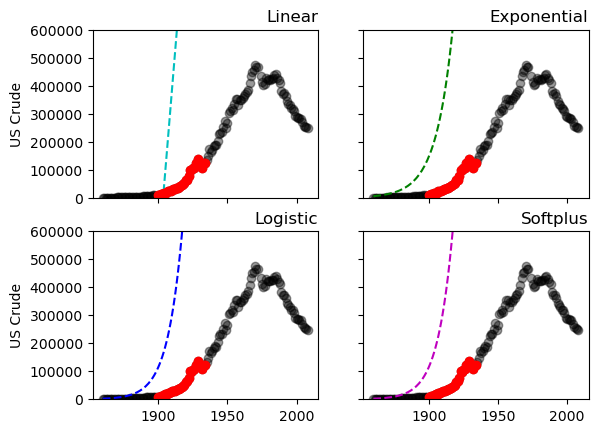

In [12]:
# plot for one set
tech_name = 'Crude Petroleum_Annual Production_US'
# tech_name = 'Biogas_Installed electricity capacity_PK'
ltrain = 35
ltest = 36
start_index = 40

fitdata = res.loc[(res['Start_index'] == start_index) & (res['technology'] == tech_name) & (res['Length_test'] == ltest) & (res['Length_train'] == ltrain)].to_dict('records')

sl = df.iloc[df.index == tech_name, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')

fig, axis = plt.subplots(2,2, sharey = True, sharex=True)

plt.ylim(0,600000)

axis[0,0].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[0,1].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[1,0].plot(years, values, 'ko', label='Historical data', alpha = 0.4)
axis[1,1].plot(years, values, 'ko', label='Historical data', alpha = 0.4)

linpopt = [fitdata[1][k] for k in ['a','b']]
axis[0,0].plot(years, linear_func(years, *linpopt), 'c--')

exppopt = [fitdata[0][k] for k in ['a','b', 'c']]
axis[0,1].plot(years, exp_func(years, *exppopt), 'g--')

logpopt = [fitdata[2][k] for k in ['a','b','c']]
axis[1,0].plot(years, logistic_func(years, *logpopt), 'b--')

# logpopt = [fitdata[2][k] for k in ['a','b','c']]
# axis[0,1].plot(years, logistic_func(years, *logpopt), 'b')
# gompopt = [fitdata[3][k] for k in ['a','b','c']]
# axis[0,1].plot(years, gompertz_func3(years, *gompopt), 'k--')
# baspopt = [fitdata[6][k] for k in ['a','b','c', 'd']]
# axis[0,1].plot(years, bass_func(years, *baspopt), '--', c='brown')
# berpopt = [fitdata[7][k] for k in ['a','b','c']]
# axis[0,1].plot(years, bertalanffy_func3(years, *berpopt), '--', c='violet')
# ricpopt = [fitdata[8][k] for k in ['a','b','c', 'd']]
# axis[0,1].plot(years, logistic_func(years, *logpopt), 'r--')

# exppopt = [fitdata[0][k] for k in ['a','b', 'c']]
# axis[1,0].plot(years, exp_func(years, *exppopt), 'g--')
# linpopt = [fitdata[1][k] for k in ['a','b']]
# axis[1,0].plot(years, linear_func(years, *linpopt), 'c--')

sofpopt = [fitdata[4][k] for k in ['a','b','c']]
axis[1,1].plot(years, softplus_func(years, *sofpopt), 'm--')
# lwcpopt = [fitdata[5][k] for k in ['a','b','c']]
# axis[1,1].plot(years, logistic_linear_cont(years, *lwcpopt), 'r--')

axis[0,0].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[0,1].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[1,0].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')
axis[1,1].plot(years[start_index:(start_index+ltrain)], values[start_index:(start_index+ltrain)], 'o', color='r')

axis[0,0].set_title('Linear', loc = 'right')
axis[0,1].set_title('Exponential', loc = 'right')
axis[1,0].set_title('Logistic', loc = 'right')
axis[1,1].set_title('Softplus', loc = 'right')

axis[0,0].set_ylabel('US Crude')
axis[1,0].set_ylabel('US Crude')

## Version 2 (based on fitting entire curve)

In [2]:
savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300} #
save_fig = True

day = '2025-03-25' #'2024-10-22'

In [3]:
metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_all_2024-11-19.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_all_2024-11-19.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [4]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Long Technology Name']]

params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [5]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
full_table = pd.merge(full_table, metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
full_table

49864
49864
56316
49864


,functional_form,fit_procedure,fit_success,r_squared,adj_r_squared,MCp,BIC,MAPE,a,b,...,Type of Adopter,Granularity Numerical,Granularity,Average lifetime,Technology Lifetime,Strict replacement,Broad replacement,Feedstock,Category Type,Patent Category Name
0,exponential,curve_fit,True,0.487690,0.481543,7.392699e+03,7.694435e+03,1.051031,99.938727,0.010812,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
1,linear,curve_fit,True,0.406591,0.401862,8.497110e+03,8.730111e+03,1.528609,-1800.686448,1.014233,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
2,logistic,curve_fit,True,0.706834,0.703316,4.230428e+03,4.403095e+03,0.760129,289.208416,0.201153,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
3,gompertz,curve_fit,True,0.699004,0.695392,4.343411e+03,4.520689e+03,0.784392,287.769586,0.171707,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
4,softplus,curve_fit,True,0.513636,0.507799,7.018306e+03,7.304761e+03,0.880879,2.500417,0.090886,...,Firms [1],Expensive,Low,NaN,Decades,No,Yes,No,Food and Health,Human Necessities
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56311,softplus,curve_fit,True,0.939718,0.909578,1.087347e+09,1.149038e+09,0.243888,39833.928385,1.002134,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56312,logistic-linear-cont,curve_fit,True,0.943906,0.915858,1.011818e+09,1.069223e+09,0.217256,260854.379276,0.613273,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56313,bass,curve_fit,True,0.924427,0.863968,1.533574e+09,1.636693e+09,0.324492,0.000001,0.008213,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions
56314,bertalanffy,curve_fit,True,0.954790,0.932185,8.154841e+08,8.617504e+08,0.314934,361733.676341,0.342151,...,Firms [1],Expensive,Low,15.0,Years,No,No,No,Materials,Fixed Constructions


In [6]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)

In [7]:
# filter for time series with good fit for different curve families

fres = full_table.loc[(full_table['functional_form'] == 'logistic') & (full_table['n'] > 30) & (full_table['Country Name'] == 'World')].sort_values('r_squared', ascending=False)
fres[['r_squared', 'technology', 'Technology Name', 'Metric', 'Unit']]

,r_squared,technology,Technology Name,Metric,Unit
29277,0.999981,Computing Growth_Computing Capacity_World,Computing Growth,Computing Capacity,"Calculations per second per $1,000"
32229,0.999895,Cellphones_Cumulative Total Capacity_World,Cellphones,Cumulative Total Capacity,MW
32967,0.999419,Internet Traffic_Computing Capacity_World,Internet Traffic,Computing Capacity,Gigabytes per month
650,0.998926,Bicycles_Cumulative Total Capacity_World,Bicycles,Cumulative Total Capacity,MW
8084,0.998848,Aquaculture Production_Annual production_World,Aquaculture Production,Annual production,metric tons
3539,0.998653,Washing Machines_Cumulative Total Capacity_World,Washing Machines,Cumulative Total Capacity,MW
3134,0.998428,Coal Power_Cumulative Total Capacity_World,Coal Power,Cumulative Total Capacity,MW
2468,0.998082,Passenger Cars_Cumulative Total Capacity_World,Passenger Cars,Cumulative Total Capacity,MW
3755,0.997791,Laundry Dryers_Cumulative Total Capacity_World,Laundry Dryers,Cumulative Total Capacity,MW
32067,0.997612,Microprocessor Clock Speed_Computing Capacity_...,Microprocessor Clock Speed,Computing Capacity,Hz


Coal Power_Cumulative Total Capacity_World


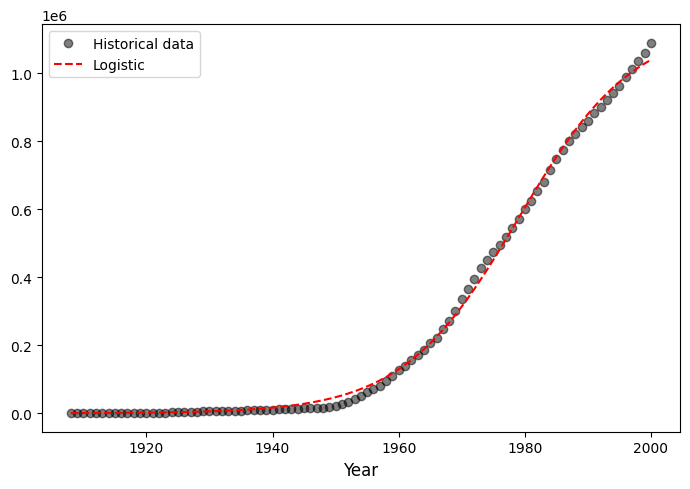

<Figure size 640x480 with 0 Axes>

In [8]:
pars = fres.iloc[6]

tech_name = pars['technology']
print(tech_name)

sl = ts.loc[ts['ID'] == tech_name].iloc[:, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')

plot_curve_fits(years, values, pars, show_plot=False, xlabel="Year")

c:\Users\zacht\Documents\Nelson\ClimateActionLab\GrowthRates\growth-measures\curve_fitting.py:556: RuntimeWarning: overflow encountered in exp
  return a * (1 - np.exp(-(d + b) * (x-c))) / (1 + (b / d) * np.exp(-(d + b) * (x - c)))
c:\Users\zacht\Documents\Nelson\ClimateActionLab\GrowthRates\growth-measures\curve_fitting.py:556: RuntimeWarning: invalid value encountered in divide
  return a * (1 - np.exp(-(d + b) * (x-c))) / (1 + (b / d) * np.exp(-(d + b) * (x - c)))


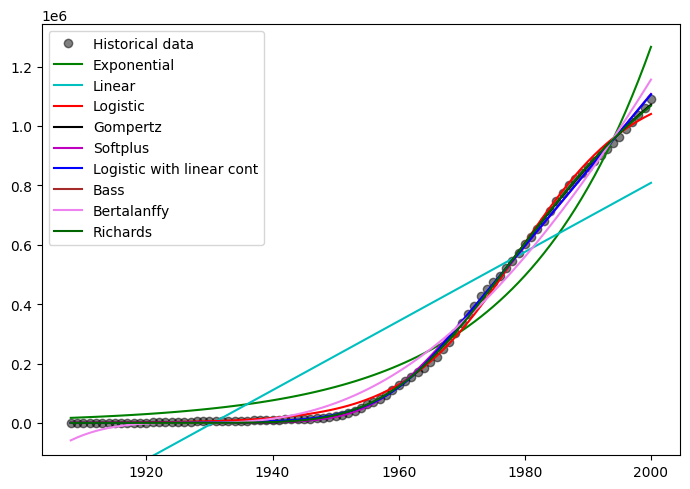

<Figure size 640x480 with 0 Axes>

In [9]:
# plot all curves for one time series
tech_name = 'Coal Power_Cumulative Total Capacity_World'

pars = full_table[full_table['technology'] == tech_name]

sl = ts.loc[ts['ID'] == tech_name].iloc[:, 9:].transpose().dropna()
years = sl.index.to_numpy(dtype='float')
values = sl.to_numpy(dtype='float')

plot_curve_fits(years, values, pars, verbosity=0, show_plot=False, linestyle='-')

## Combine different families of functional forms

In [10]:
ts['Unit'].unique()

array(['thousand metric tons', 'thousand hectolitres', 'kilometers', '-',
       'Number (millions)', 'metric tons', 'MW', 'miles',
       'thousand tons of nitrogen equivalent', '%', 'TWh',
       'thousand barrels', 'million metric tons', 'billion cubic meters',
       'GW', 'Short tons', 'Calculations per second per $1,000',
       'Bits per dollar', 'billion cubic feet', 'Hz', 'Petajoule',
       'Gigabytes per month', 'kW', 'kWh', 'Bits/second', 'GWe', 'Acres',
       'million pounds', 'billion barrels', 'net tons', 'million gallons',
       'billion pounds', 'Million instructions per second (MIPS)',
       'Transistors per microprocessor', 'Million cubic meters per day',
       'kilobase', 'MWt'], dtype=object)

In [11]:
def plot_selection(tech_name, functional_forms, fit_results, timeseries, ax=None, title=''):
    pars = fit_results[(fit_results['technology'] == tech_name) & fit_results['functional_form'].isin(functional_forms)]

    sl = timeseries.loc[ts['ID'] == tech_name].iloc[:, 9:].transpose().dropna()
    unit = timeseries.loc[ts['ID'] == tech_name]['Unit'].item()
    tech_name = tech_name.split("_")
    ylabel = tech_name[2]+" "+tech_name[0]+"\n"+tech_name[1]+" ("+unit+")"
    years = sl.index.to_numpy(dtype='float')
    values = sl.to_numpy(dtype='float')

    #tech_name=tech_name, 
    return plot_curve_fits(years, values, pars, verbosity=0, show_plot=False, linestyle='-', ax=ax, ylabel=ylabel, xlabel="Year",title=title) 

In [12]:
# identify time series with high goodness of fit
fres = full_table.loc[(full_table['functional_form'] == 'softplus') & (full_table['n'] > 30) & (full_table['Country Name'] == 'World')].sort_values('r_squared', ascending=False)
fres[['r_squared', 'technology', 'Technology Name', 'Metric', 'Unit']]

,r_squared,technology,Technology Name,Metric,Unit
29279,0.999981,Computing Growth_Computing Capacity_World,Computing Growth,Computing Capacity,"Calculations per second per $1,000"
32231,0.999901,Cellphones_Cumulative Total Capacity_World,Cellphones,Cumulative Total Capacity,MW
3757,0.999841,Laundry Dryers_Cumulative Total Capacity_World,Laundry Dryers,Cumulative Total Capacity,MW
3541,0.999682,Washing Machines_Cumulative Total Capacity_World,Washing Machines,Cumulative Total Capacity,MW
32968,0.999570,Internet Traffic_Computing Capacity_World,Internet Traffic,Computing Capacity,Gigabytes per month
3136,0.999147,Coal Power_Cumulative Total Capacity_World,Coal Power,Cumulative Total Capacity,MW
2470,0.999004,Passenger Cars_Cumulative Total Capacity_World,Passenger Cars,Cumulative Total Capacity,MW
8086,0.998803,Aquaculture Production_Annual production_World,Aquaculture Production,Annual production,metric tons
652,0.998676,Bicycles_Cumulative Total Capacity_World,Bicycles,Cumulative Total Capacity,MW
3190,0.998170,Refrigerators_Cumulative Total Capacity_World,Refrigerators,Cumulative Total Capacity,MW


In [13]:
# only look at results that are not fitted well by exponential
fres = full_table.loc[(full_table['functional_form'] == 'logistic') & (full_table['n'] > 30) & (full_table['Country Name'] == 'World')].sort_values('r_squared', ascending=False)

ffres = fres[fres['technology'].isin(full_table.loc[(full_table['functional_form'] == 'exponential') & (full_table['r_squared'] < 0.90)]['technology'])]
ffres[['functional_form', 'r_squared', 'technology', 'Technology Name', 'Metric', 'Unit']]

,functional_form,r_squared,technology,Technology Name,Metric,Unit
13691,logistic,0.994083,Nuclear Energy_Annual Production_World,Nuclear Energy,Annual Production,TWh
6131,logistic,0.978550,FCC-Refineries_Net Total Capacity_World,Fluid Catalytic Cracking Refineries,Net Total Capacity,MW
1640,logistic,0.977393,Cadmium Refining_Annual production_World,Cadmium Refining,Annual production,metric tons
11126,logistic,0.935460,Capture Fisheries_Annual production_World,Capture Fisheries,Annual production,metric tons
13772,logistic,0.912312,Oil Production_Annual Production_World,Oil Production,Annual Production,million metric tons
1622,logistic,0.895735,Graphite_Annual production_World,Graphite,Annual production,metric tons
29475,logistic,0.888275,Random Access Memory_Computing Capacity_World,Random Access Memory,Computing Capacity,Bits per dollar
26361,logistic,0.886870,Coal Production_Annual Production_World,Coal Production,Annual Production,million metric tons
6376,logistic,0.881102,Space Launches_Total Number_World,Space Launches,Total Number,-
3017,logistic,0.873364,Lithium Mine Production_Annual production_World,Lithium Mine Production,Annual production,metric tons


c:\Users\zacht\Documents\Nelson\ClimateActionLab\GrowthRates\growth-measures\curve_fitting.py:556: RuntimeWarning: overflow encountered in exp
  return a * (1 - np.exp(-(d + b) * (x-c))) / (1 + (b / d) * np.exp(-(d + b) * (x - c)))
c:\Users\zacht\Documents\Nelson\ClimateActionLab\GrowthRates\growth-measures\curve_fitting.py:556: RuntimeWarning: invalid value encountered in divide
  return a * (1 - np.exp(-(d + b) * (x-c))) / (1 + (b / d) * np.exp(-(d + b) * (x - c)))


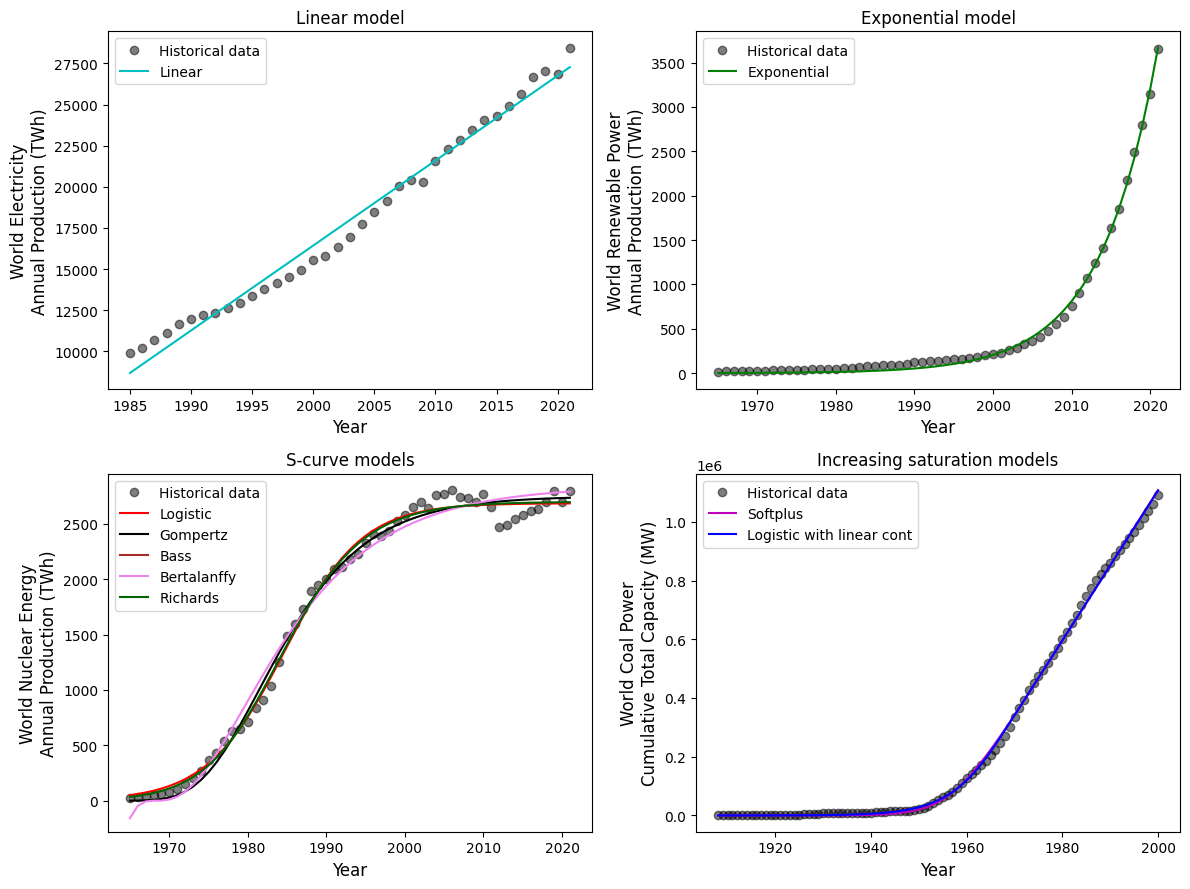

In [14]:
# plot all curves for one time series

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# Linear
tech_name = 'Electricity_Annual Production_World'
functional_forms = ['linear']
axis = plot_selection(tech_name, functional_forms, full_table, ts, ax=ax[0][0], title='Linear model')

# Exponential
tech_name = 'Renewable Power_Annual Production_World'
functional_forms = ['exponential']
axis = plot_selection(tech_name, functional_forms, full_table, ts, ax=ax[0][1], title='Exponential model')

# S-curves
tech_name = 'Nuclear Energy_Annual Production_World'
functional_forms = ['logistic', 'gompertz', 'bass', 'bertalanffy', 'richards']
axis = plot_selection(tech_name, functional_forms, full_table, ts, ax=ax[1][0], title='S-curve models')

# Softplus / logistic with linear continuation
tech_name = 'Coal Power_Cumulative Total Capacity_World'
functional_forms = ['softplus', 'logistic-linear-cont']
axis = plot_selection(tech_name, functional_forms, full_table, ts, ax=ax[1][1], title='Increasing saturation models')

if save_fig:
    fig.savefig('figures/paper_fig1_functional_form_illustrations.png', **savefig_settings)